In [2]:
from typing import TypedDict, List
from langgraph.graph import StateGraph, END

In [ ]:
class AgentState(TypedDict):
    message : str

def greeting_node(state: AgentState) -> AgentState:
    return {
        "message": state["message"] + " you're doing amazing job learning LangGraph!"
    }
graph= StateGraph(AgentState)
graph.add_node("greet", greeting_node)
graph.set_entry_point("greet")
graph.add_edge("greet" ,END)

app = graph.compile()

result = app.invoke({"message" : "3AM rain"})
print(result["message"])

3AM rain you're doing amazing job learning LangGraph!


In [4]:
class AgentState(TypedDict):
    values : List[int]
    name : str
    result : str

In [ ]:
def process_values(state: AgentState) -> AgentState:
    """Handles multiple inputs and computes sum"""

    state["result"] = f"hi there {state['name']} your sum = {sum(state['values'])}"

    return state


In [14]:
graph = StateGraph(AgentState)

graph.add_node("processor", process_values)
graph.set_entry_point("processor")
graph.set_finish_point("processor")

app = graph.compile()

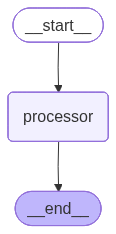

In [17]:
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))